In [ ]:
!pip install opencv-python mediapipe pyautogui

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 866.9 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.2/171.2 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.0 MB/s eta 0:00:00
  Created wheel for pyautogui: filename=pyautogui-0.9.54-py3-none-any.whl size=37683 sha256=bc3995df4a2f9b25d422fda4a3217d5

Found existing installation: mediapipe 0.10.33
Uninstalling mediapipe-0.10.33:
  Successfully uninstalled mediapipe-0.10.33
ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.9 (from versions: 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21, 0.10.30, 0.10.31, 0.10.32, 0.10.33)
ERROR: No matching distribution found for mediapipe==0.10.9
✅ MediaPipe version: 0.10.33
🤚 HAND GESTURE RECOGNITION SYSTEM

📋 This system uses MediaPipe for hand landmark detection
   and recognizes various hand gestures from images.

🔧 Checking dependencies...
❌ Error initializing HandTracker: module 'mediapipe' has no attribute 'solutions'
⚠️  Some features may be limited

📌 MAIN MENU
1. 🖼️  Upload Single Image
2. 📸 Multiple Images Batch Processing
3. 🎥 Capture from Webcam (Single Frame)
4. 📖 View Gesture Guide
5. ❌ Exit

📤 Please upload an image file with a hand...
Supported formats: JPG, PNG, JPEG


Saving photo-1600821462314-9dcebd4e7a2f.avif to photo-1600821462314-9dcebd4e7a2f (2).avif

🖐️ Processing: photo-1600821462314-9dcebd4e7a2f (2).avif
❌ Error initializing HandTracker: module 'mediapipe' has no attribute 'solutions'
❌ HandTracker failed to initialize!

📌 MAIN MENU
1. 🖼️  Upload Single Image
2. 📸 Multiple Images Batch Processing
3. 🎥 Capture from Webcam (Single Frame)
4. 📖 View Gesture Guide
5. ❌ Exit

📤 Please upload an image file with a hand...
Supported formats: JPG, PNG, JPEG


Saving ok-gesture-woman-hand.jpg to ok-gesture-woman-hand.jpg

🖐️ Processing: ok-gesture-woman-hand.jpg
❌ Error initializing HandTracker: module 'mediapipe' has no attribute 'solutions'
❌ HandTracker failed to initialize!

📌 MAIN MENU
1. 🖼️  Upload Single Image
2. 📸 Multiple Images Batch Processing
3. 🎥 Capture from Webcam (Single Frame)
4. 📖 View Gesture Guide
5. ❌ Exit


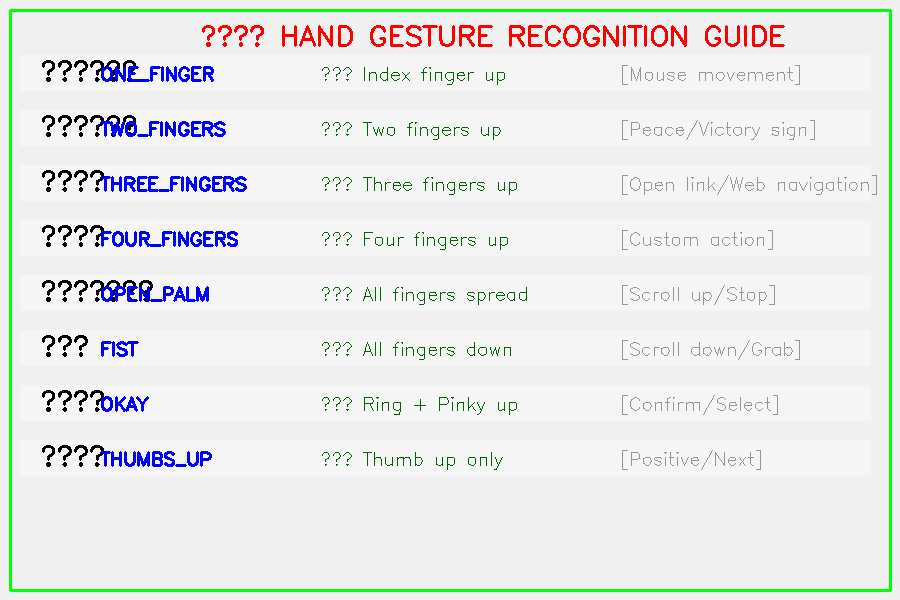


📌 MAIN MENU
1. 🖼️  Upload Single Image
2. 📸 Multiple Images Batch Processing
3. 🎥 Capture from Webcam (Single Frame)
4. 📖 View Gesture Guide
5. ❌ Exit


In [ ]:
# Combined Hand Gesture Recognition System for Google Colab
# Fixed MediaPipe import issue

import cv2
import numpy as np
import math
from google.colab.patches import cv2_imshow
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Install required packages
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.9 opencv-python -q

# Import MediaPipe with proper error handling
try:
    import mediapipe as mp
    print(f"✅ MediaPipe version: {mp.__version__}")
    HAS_MEDIA_PIPE = True
except ImportError as e:
    print(f"❌ MediaPipe import error: {e}")
    print("Reinstalling MediaPipe...")
    !pip install mediapipe==0.10.9 -q
    import mediapipe as mp
    HAS_MEDIA_PIPE = True

# ============== HandTracker Class ==============
class HandTracker:
    def __init__(self, static_image_mode=False, max_num_hands=1, min_detection_confidence=0.7, min_tracking_confidence=0.7):
        try:
            self.mp_hands = mp.solutions.hands
            self.hands = self.mp_hands.Hands(
                static_image_mode=static_image_mode,
                max_num_hands=max_num_hands,
                min_detection_confidence=min_detection_confidence,
                min_tracking_confidence=min_tracking_confidence
            )
            self.mp_draw = mp.solutions.drawing_utils
            self.mp_drawing_styles = mp.solutions.drawing_styles
            self.tip_ids = [4, 8, 12, 16, 20]  # Thumb, Index, Middle, Ring, Pinky
            self.initialized = True
            print("✅ HandTracker initialized successfully")
        except Exception as e:
            print(f"❌ Error initializing HandTracker: {e}")
            self.initialized = False

    def find_hands(self, img, draw=True):
        if not self.initialized:
            return img

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        self.results = self.hands.process(img_rgb)

        if self.results.multi_hand_landmarks:
            for hand_lms in self.results.multi_hand_landmarks:
                if draw:
                    # Draw landmarks with improved styling
                    self.mp_draw.draw_landmarks(
                        img,
                        hand_lms,
                        self.mp_hands.HAND_CONNECTIONS,
                        self.mp_drawing_styles.get_default_hand_landmarks_style(),
                        self.mp_drawing_styles.get_default_hand_connections_style()
                    )
        return img

    def get_position(self, img, hand_no=0):
        lms_list = []
        if not self.initialized:
            return lms_list

        if self.results and self.results.multi_hand_landmarks:
            if hand_no < len(self.results.multi_hand_landmarks):
                my_hand = self.results.multi_hand_landmarks[hand_no]
                h, w, c = img.shape
                for id, lm in enumerate(my_hand.landmark):
                    cx, cy = int(lm.x * w), int(lm.y * h)
                    lms_list.append([id, cx, cy])
        return lms_list

    def get_fingers_up(self, lms_list):
        fingers = []
        if len(lms_list) == 0 or not self.initialized:
            return fingers

        try:
            # Thumb: compare x coordinates
            if lms_list[self.tip_ids[0]][1] > lms_list[self.tip_ids[0] - 1][1]:
                fingers.append(1)
            else:
                fingers.append(0)

            # Other 4 fingers
            for id in range(1, 5):
                if lms_list[self.tip_ids[id]][2] < lms_list[self.tip_ids[id] - 2][2]:
                    fingers.append(1)
                else:
                    fingers.append(0)
        except IndexError:
            pass

        return fingers

# ============== GestureRecognizer Class ==============
class GestureRecognizer:
    def __init__(self):
        self.gesture_names = {
            "ONE_FINGER": "☝️ One Finger - Pointing",
            "TWO_FINGERS": "✌️ Two Fingers - Peace/Victory",
            "THREE_FINGERS": "🤟 Three Fingers - Rock",
            "FOUR_FINGERS": "🖖 Four Fingers - Spock",
            "OPEN_PALM": "🖐️ Open Palm - Stop/Scroll Up",
            "FIST": "✊ Fist - Scroll Down",
            "OKAY": "👌 Okay Sign",
            "THUMBS_UP": "👍 Thumbs Up",
            "THUMBS_DOWN": "👎 Thumbs Down",
            "UNKNOWN": "❓ Unknown Gesture"
        }

    def recognize(self, fingers):
        if not fingers or len(fingers) != 5:
            return "UNKNOWN"

        # Complete finger status including thumb
        thumb = fingers[0]
        four_fingers = fingers[1:]  # Index, Middle, Ring, Pinky

        # Detailed gesture recognition
        if four_fingers == [1, 1, 1, 1]:
            return "OPEN_PALM"
        elif four_fingers == [0, 0, 0, 0]:
            return "FIST"
        elif four_fingers == [1, 0, 0, 0]:
            return "ONE_FINGER"
        elif four_fingers == [1, 1, 0, 0]:
            return "TWO_FINGERS"
        elif four_fingers == [1, 1, 1, 0]:
            return "THREE_FINGERS"
        elif four_fingers == [1, 1, 1, 1]:
            return "FOUR_FINGERS"
        elif four_fingers == [0, 1, 1, 1] and thumb == 0:
            return "OKAY"
        elif fingers == [1, 0, 0, 0, 0] and thumb == 1:
            return "THUMBS_UP"
        elif fingers == [0, 0, 0, 0, 0] and thumb == 0:
            return "THUMBS_DOWN"

        return "UNKNOWN"

    def get_gesture_info(self, gesture):
        return self.gesture_names.get(gesture, "Unknown gesture")

# ============== Test with Sample Hand Image ==============
def create_test_hand_visualization():
    """Create a visualization of different hand gestures"""

    # Create a blank image
    img = np.ones((600, 900, 3), dtype=np.uint8) * 240

    # Gesture information
    gestures_info = [
        ("ONE_FINGER", "☝️", "Index finger up", "Mouse movement"),
        ("TWO_FINGERS", "✌️", "Two fingers up", "Peace/Victory sign"),
        ("THREE_FINGERS", "🤟", "Three fingers up", "Open link/Web navigation"),
        ("FOUR_FINGERS", "🖖", "Four fingers up", "Custom action"),
        ("OPEN_PALM", "🖐️", "All fingers spread", "Scroll up/Stop"),
        ("FIST", "✊", "All fingers down", "Scroll down/Grab"),
        ("OKAY", "👌", "Ring + Pinky up", "Confirm/Select"),
        ("THUMBS_UP", "👍", "Thumb up only", "Positive/Next")
    ]

    # Display gesture guide
    cv2.rectangle(img, (10, 10), (890, 590), (0, 255, 0), 2)
    cv2.putText(img, "🤚 HAND GESTURE RECOGNITION GUIDE", (200, 45),
               cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    y_start = 80
    for i, (gesture, emoji, description, action) in enumerate(gestures_info):
        y_pos = y_start + i * 55
        # Background for each row
        cv2.rectangle(img, (20, y_pos - 25), (870, y_pos + 10), (245, 245, 245), -1)
        cv2.putText(img, f"{emoji}", (40, y_pos),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2)
        cv2.putText(img, f"{gesture}", (100, y_pos),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        cv2.putText(img, f"→ {description}", (320, y_pos),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 100, 0), 1)
        cv2.putText(img, f"[{action}]", (620, y_pos),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (150, 150, 150), 1)

    cv2_imshow(img)
    return img

# ============== Process Uploaded Image ==============
def process_uploaded_image():
    """Process uploaded images for hand gesture recognition"""
    print("\n📤 Please upload an image file with a hand...")
    print("Supported formats: JPG, PNG, JPEG")

    uploaded = files.upload()

    if not uploaded:
        print("❌ No file uploaded!")
        return None, None

    for filename in uploaded.keys():
        print(f"\n🖐️ Processing: {filename}")

        # Read image
        img = cv2.imread(filename)
        if img is None:
            print(f"❌ Failed to read {filename}")
            continue

        # Resize if too large
        height, width = img.shape[:2]
        if width > 800:
            scale = 800 / width
            new_width = int(width * scale)
            new_height = int(height * scale)
            img = cv2.resize(img, (new_width, new_height))

        # Flip for selfie view
        img = cv2.flip(img, 1)
        original = img.copy()

        # Initialize tracker and recognizer
        tracker = HandTracker(
            static_image_mode=True,  # Better for static images
            min_detection_confidence=0.5
        )
        recognizer = GestureRecognizer()

        if not tracker.initialized:
            print("❌ HandTracker failed to initialize!")
            return None, None

        # Process image
        img = tracker.find_hands(img)
        lms_list = tracker.get_position(img)

        gesture = "UNKNOWN"
        fingers_up = []

        if len(lms_list) != 0:
            fingers_up = tracker.get_fingers_up(lms_list)
            gesture = recognizer.recognize(fingers_up)

            # Display finger count on image
            finger_count = sum(fingers_up)

            # Create info panel
            overlay = img.copy()
            cv2.rectangle(overlay, (5, 5), (300, 140), (0, 0, 0), -1)
            img = cv2.addWeighted(overlay, 0.7, img, 0.3, 0)

            # Display information
            cv2.putText(img, f"Gesture: {gesture}", (15, 35),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            cv2.putText(img, f"Fingers: {finger_count}", (15, 65),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

            # Show individual finger status
            finger_names = ['Thumb', 'Index', 'Middle', 'Ring', 'Pinky']
            y_offset = 95
            for i, (name, is_up) in enumerate(zip(finger_names, fingers_up)):
                color = (0, 255, 0) if is_up else (0, 0, 255)
                status = "⬆️ UP" if is_up else "⬇️ DOWN"
                cv2.putText(img, f"{name}: {status}", (15, y_offset + i * 18),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

            # Draw centers on fingertips
            for tip_id in tracker.tip_ids:
                if tip_id < len(lms_list):
                    x, y = lms_list[tip_id][1], lms_list[tip_id][2]
                    cv2.circle(img, (x, y), 8, (0, 255, 255), -1)
                    cv2.circle(img, (x, y), 12, (255, 255, 0), 2)

        else:
            cv2.putText(img, "❌ No hand detected!", (50, 100),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
            cv2.putText(img, "Tips: Good lighting + clear background", (50, 150),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

        # Display the result
        print(f"\n✅ Recognition Results:")
        print(f"   • Gesture: {gesture}")
        print(f"   • Description: {recognizer.get_gesture_info(gesture)}")
        print(f"   • Finger status: {fingers_up}")
        print(f"   • Total fingers up: {sum(fingers_up)}")

        cv2_imshow(img)

        return gesture, fingers_up

# ============== Webcam Capture (Colab compatible) ==============
def run_webcam_demo():
    """Run webcam-based gesture recognition using JavaScript capture"""
    from IPython.display import display, Javascript, Image
    from base64 import b64decode
    import ipywidgets as widgets
    from IPython.display import clear_output

    print("\n🎥 Setting up webcam capture...")
    print("📸 This will capture a single frame from your webcam")
    print("⚠️  You must grant camera permission when prompted!")

    # JavaScript to capture webcam photo
    js = Javascript('''
        async function capturePhoto() {
            const div = document.createElement('div');
            const video = document.createElement('video');
            const canvas = document.createElement('canvas');
            document.body.appendChild(div);
            div.appendChild(video);

            try {
                const stream = await navigator.mediaDevices.getUserMedia({video: true});
                video.srcObject = stream;
                await video.play();

                // Wait for camera to initialize
                await new Promise(r => setTimeout(r, 1000));

                canvas.width = video.videoWidth;
                canvas.height = video.videoHeight;
                canvas.getContext('2d').drawImage(video, 0, 0);

                const photo = canvas.toDataURL('image/jpeg');
                stream.getTracks().forEach(track => track.stop());
                div.remove();

                return photo;
            } catch(err) {
                console.error("Camera error:", err);
                return "ERROR: " + err.message;
            }
        }
    ''')

    display(js)

    try:
        # Capture photo
        photo_data = eval_js('capturePhoto()')

        if photo_data.startswith("ERROR:"):
            print(f"❌ {photo_data}")
            print("💡 Make sure you've granted camera permissions!")
            return None, None

        # Decode image
        photo_data = photo_data.split(',')[1]
        img_data = b64decode(photo_data)
        nparr = np.frombuffer(img_data, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if img is None:
            print("❌ Failed to capture image!")
            return None, None

        # Process the captured image
        img = cv2.flip(img, 1)

        tracker = HandTracker(static_image_mode=True, min_detection_confidence=0.5)
        recognizer = GestureRecognizer()

        if not tracker.initialized:
            print("❌ HandTracker failed to initialize!")
            return None, None

        img = tracker.find_hands(img)
        lms_list = tracker.get_position(img)

        gesture = "UNKNOWN"
        fingers_up = []

        if len(lms_list) != 0:
            fingers_up = tracker.get_fingers_up(lms_list)
            gesture = recognizer.recognize(fingers_up)

            # Add overlay information
            overlay = img.copy()
            cv2.rectangle(overlay, (5, 5), (350, 120), (0, 0, 0), -1)
            img = cv2.addWeighted(overlay, 0.6, img, 0.4, 0)

            finger_count = sum(fingers_up)
            cv2.putText(img, f"Gesture: {gesture}", (15, 35),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            cv2.putText(img, f"Fingers: {finger_count}", (15, 65),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

        else:
            cv2.putText(img, "No hand detected!", (50, 100),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        print(f"\n✅ Recognition Results:")
        print(f"   • Gesture: {gesture}")
        print(f"   • Description: {recognizer.get_gesture_info(gesture)}")
        print(f"   • Finger status: {fingers_up}")

        # Display the image
        print("\n📸 Captured and processed image:")
        cv2_imshow(img)

        return gesture, fingers_up

    except Exception as e:
        print(f"❌ Error: {e}")
        print("💡 Try refreshing the page and granting camera permission again.")
        return None, None

# ============== Batch Process Images ==============
def batch_process_images():
    """Process multiple uploaded images at once"""
    print("\n📤 Upload multiple images for batch processing...")
    print("Select all images you want to process")

    uploaded = files.upload()

    if not uploaded:
        print("❌ No files uploaded!")
        return []

    tracker = HandTracker(static_image_mode=True, min_detection_confidence=0.5)
    recognizer = GestureRecognizer()

    if not tracker.initialized:
        print("❌ HandTracker failed to initialize!")
        return []

    results = []

    print("\n🔄 Processing images...\n")

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is None:
            print(f"❌ {filename}: Failed to read")
            continue

        # Resize if needed
        height, width = img.shape[:2]
        if width > 800:
            scale = 800 / width
            new_width = int(width * scale)
            new_height = int(height * scale)
            img = cv2.resize(img, (new_width, new_height))

        img = cv2.flip(img, 1)
        img = tracker.find_hands(img)
        lms_list = tracker.get_position(img)

        if len(lms_list) != 0:
            fingers_up = tracker.get_fingers_up(lms_list)
            gesture = recognizer.recognize(fingers_up)
            results.append({
                'filename': filename,
                'gesture': gesture,
                'fingers_up': fingers_up,
                'finger_count': sum(fingers_up)
            })
            print(f"✅ {filename}: {gesture} ({sum(fingers_up)} fingers)")
        else:
            print(f"❌ {filename}: No hand detected")
            results.append({
                'filename': filename,
                'gesture': 'NO_HAND',
                'fingers_up': [],
                'finger_count': 0
            })

    # Display summary
    print("\n" + "="*50)
    print("📊 BATCH PROCESSING SUMMARY")
    print("="*50)

    for r in results:
        status = "✓" if r['gesture'] != 'NO_HAND' else "✗"
        print(f"{status} {r['filename']}: {r['gesture']} - {r['finger_count']} fingers")

    return results

# ============== Main Menu System ==============
def main():
    print("="*60)
    print("🤚 HAND GESTURE RECOGNITION SYSTEM")
    print("="*60)
    print("\n📋 This system uses MediaPipe for hand landmark detection")
    print("   and recognizes various hand gestures from images.")

    # Test MediaPipe installation
    print("\n🔧 Checking dependencies...")
    try:
        test_tracker = HandTracker()
        if test_tracker.initialized:
            print("✅ All systems ready!")
        else:
            print("⚠️  Some features may be limited")
    except:
        print("⚠️  Please ensure stable internet connection for first run")

    while True:
        print("\n" + "="*40)
        print("📌 MAIN MENU")
        print("="*40)
        print("1. 🖼️  Upload Single Image")
        print("2. 📸 Multiple Images Batch Processing")
        print("3. 🎥 Capture from Webcam (Single Frame)")
        print("4. 📖 View Gesture Guide")
        print("5. ❌ Exit")

        choice = input("\n👉 Enter your choice (1-5): ").strip()

        if choice == '1':
            process_uploaded_image()

        elif choice == '2':
            batch_process_images()

        elif choice == '3':
            print("\n⚠️  Note: Webcam access requires browser permission")
            confirm = input("Continue? (y/n): ").lower()
            if confirm == 'y':
                run_webcam_demo()
            else:
                print("❌ Cancelled.")

        elif choice == '4':
            create_test_hand_visualization()

        elif choice == '5':
            print("\n👋 Thank you for using Hand Gesture Recognition System!")
            print("   Created with MediaPipe & OpenCV")
            break

        else:
            print("❌ Invalid choice! Please enter 1-5")

# ============== Run the Application ==============
if __name__ == "__main__":
    main()